In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import PolynomialFeatures
from math import ceil
from sklearn.model_selection import learning_curve
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
import math
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split






# Linear Regression

1. Solve normal equation
2. Use SVD (sklearn.LinearRegression) to solve closed form
3. Batch Gradient Descent
4. Stochastic GD (sklearn.SGDRegressor)
5. Mini-batch GD

__Normal Equation__:

$\hat{\theta} =(\mathbf{X^{T}X})^{-1}\mathbf{X^{T}y}$

In [3]:
rng = np.random.default_rng(seed=42)
m = 200
X = 2 * rng.random((m,1))
y = 4 + 3 * X + rng.standard_normal((m,1))    #theta = 4 and 3

In [4]:
y.ravel().shape

(200,)

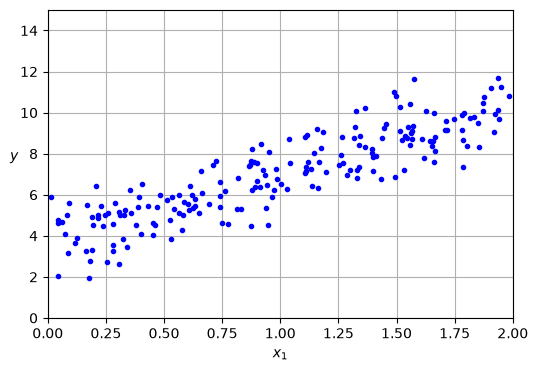

In [10]:
plt.figure(figsize=(6,4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0,2,0,15])
plt.grid()
plt.show()
        

In [10]:
from sklearn.preprocessing import add_dummy_feature
X_b = add_dummy_feature(X)  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [11]:
theta_best  #ideally [[4],[3]]

array([[3.69084138],
       [3.32960458]])

In [14]:
X.shape

(200, 1)

In [15]:
#make predictions

X_new = np.array([[0],[2]])     
X_new_b = add_dummy_feature(X_new)  #add x0 = 1 to each instance
X_new_b

array([[1., 0.],
       [1., 2.]])

In [17]:
y_predict = X_new_b @ theta_best
y_predict

array([[ 3.69084138],
       [10.35005055]])

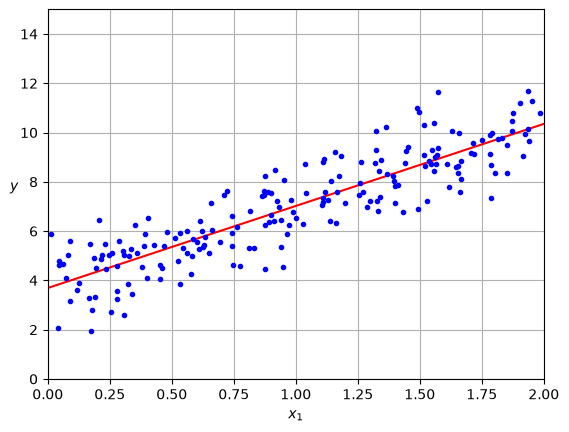

In [27]:
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0,2,0,15])
plt.grid()
plt.show()rng


Using Scikit-learn

In [5]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[3.33]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[3.69]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[7.96]


In [29]:
lin_reg.intercept_, lin_reg.coef_

(array([3.69084138]), array([[3.32960458]]))

In [31]:
lin_reg.predict(X_new) #compare to previous

array([[ 3.69084138],
       [10.35005055]])

The Scikit-learn LinearRegression class is based on scipy.linalg.lstsq() function, let's call directly
and compare

In [32]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[3.69084138],
       [3.32960458]])

#### Computational complexity of Linear Regression
Training/fitting is $O(n^{2})$ (using Singular value decomposition) w.r.t the model parameters and $O(m)$ i.e 
linear w.r.t the number of instances. Once training is doen, prediction is linear with regard to both the
number of instances and the number of features.  
When there is a very large number of features it is better to use __Gradient Descent__

## Batch Gradient Descent

Random initialization of the parameter vector $\mathbf{\theta}$  
The partial derivative of the cost function w.r.t to feature _j_:

$$ \frac{\partial}{\partial\theta_{j}}  MSE(\theta) = \frac{2}{m}\sum_{i=1}^{m}(\theta^T\mathbf{x}^{(i)})- y^{(i)})x_j^{(i)}$$

We compute them all at once (in 'batches'), a gradient vector of the cost function:
$$ \frac{2}{m}\mathbf{X^T}(\mathbf{X}\theta - y) $$
Gradient descent scales well with the number of features.

The gradient descent step:

$$ \theta^{(next step)} = \theta - \eta\delta_\theta MSE(\theta) $$
where $\eta$ is the __learning rate__

In [33]:
eta = 0.1  #learning rate
n_epochs = 1000
m = len(X_b) 

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2,1))  #randomly initialized parameters

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta -y)
    theta = theta - eta * gradients

In [34]:
theta

array([[3.69084138],
       [3.32960458]])

Batch gradient descent uses the whole training set to compute the gradients at every step.

### Stochastic Gradient Descent
Picks a random instance in the training set at every instance.  
A new learning rate is chosen at each iteration - the _learning schedule_  
A tolerance level is chosen because SGD does not automatically converge to the global minimum

In [35]:
n_epochs = 50
t0,t1 =5,50  #learning schedule hyperparameters

def learning_schedule(t):
    return t0/(t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2,1))  #randomly initialized parameters

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index: random_index + 1]
        yi = y[random_index: random_index + 1]
        gradients = 2 * xi.T @ (xi @theta -yi)  #for SGD do not divide by m
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients


In [36]:
theta

array([[3.69826475],
       [3.30748311]])

Should always shuffle the instances during training to ensure they are independent and identically distributed

In [17]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty =None, eta0=0.01, n_iter_no_change=100,
                       random_state=42)
sgd_reg.fit(X, y.ravel())  #y.ravel() because fit() expects a 1D target
                       

,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",None
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",1e-05
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_iter_no_change n_iter_no_change: int, default=5Number of iterations with no improvement to wait before stoppingfitting.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Integer values must be in the range `[1, max_iter)`... versionadded:: 0.20 Added 'n_iter_no_change' option",100
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0


In [41]:
sgd_reg.intercept_, sgd_reg.coef_

(array([3.68899733]), array([3.33054574]))

### Mini-Batch Gradient Descent
Mini-batch instead of single instance or full training set.  Can get a performance boost from 
hardware acceleration of matrix operations (vs stochastic gd)

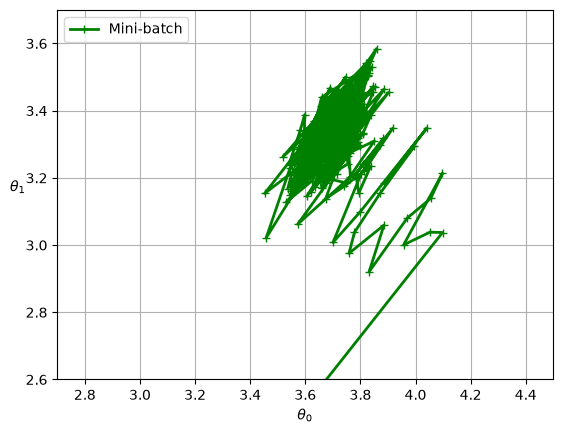

In [12]:
from math import ceil
n_epochs = 50
minibatch_size= 20
n_batches_per_epoch = ceil(m/minibatch_size)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2,1))  #randomly initialized model parameters

t0, t1 = 200, 1000 #learning schedule hyperparameters
def learning_schedule(t):
    return t0 / (t + t1)

theta_path_mgd =[]
for epoch in range(n_epochs):
    shuffled_indices = rng.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for iteration in range(0, n_batches_per_epoch):
        idx = iteration * minibatch_size
        xi = X_b_shuffled[idx: idx + minibatch_size]
        yi = y_shuffled[idx: idx + minibatch_size]
        gradients = 2/ minibatch_size * xi.T @ (xi @ theta -yi)
        eta = learning_schedule(epoch * n_batches_per_epoch + iteration)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)

theta_path_mgd = np.array(theta_path_mgd)
plt.plot(theta_path_mgd[:,0], theta_path_mgd[:,1],"g-+", linewidth=2, label= "Mini-batch")
plt.legend(loc="upper left")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$ ", rotation=0)
plt.axis([2.7,4.5,2.6,3.7])
plt.grid()
plt.show()

# Polynomial Regression

In [44]:
m = 200
X= 6 * rng.random((m,1)) - 3
y = 0.5 * X **2 + X + 2 + rng.standard_normal((m, 1))

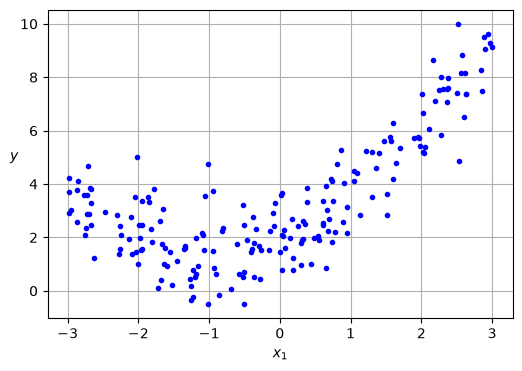

In [45]:
plt.figure(figsize=(6,4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
#plt.axis([0,2,0,15])
plt.grid()
plt.show()

We add new features for powers of features and train a linear model on this extended set of features.  
It adds $x^2$ as an extra feature, in this case. In general it transforms an array containing $n$ features  
into an array containing $(n+d)/d!n!$ features

In [25]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

In [69]:
poly_features.get_feature_names_out()

array(['x0', 'x0^2'], dtype=object)

In [51]:
X_poly[0], X[0]

(array([1.60116912, 2.56374256]), array([1.60116912]))

In [52]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.97002587]), array([[0.99105766, 0.51368255]]))

In [60]:
X_new= np.linspace(-3,3,100).reshape(100,1)

In [61]:
X_new_poly =poly_features.transform(X_new)

In [62]:
y_pred = lin_reg.predict(X_new_poly)


In [70]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

big_poly = PolynomialFeatures(degree=300, include_bias=False)
polynomial_regression = make_pipeline(big_poly, StandardScaler(),lin_reg)
polynomial_regression.fit(X,y)
y_big = polynomial_regression.predict(X_new)

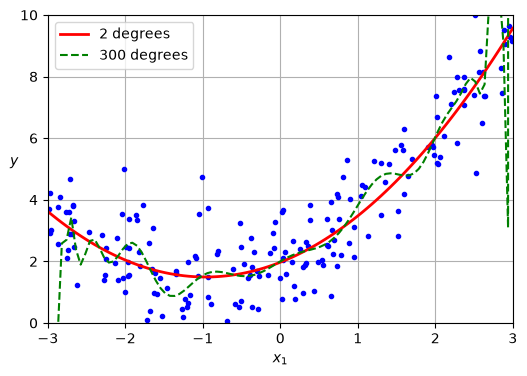

In [72]:
plt.figure(figsize=(6,4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_pred, "r-", label="2 degrees", linewidth=2)
plt.plot(X_new, y_big, "g--", label="300 degrees", linewidth=1.5)
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3,3,0,10])
plt.grid()
plt.show()

__Three typed of model generalization errors__:  
_Bias_:  Due to wrong assumptions such as assuming the model is linear when it is quadratic (tends to underfit)    
_Variance_:  Due to excessive sensitivity to small variations in the training data (tends to overfit)    
_Irreducible error_:  Due to noisiness in the data itself. Only way to reduce this is to clean up the data itself

Increasing a model's complexity increases its variance and reduces it's bias  
If a model is underfitting training data, adding more training examples will not help. You need to use a better model or come up with better features  
If a model is overfitting,one way to improve is to add more training data until the validation error gets close enough to the training error. Another good way is to regularize the model: fewer degrees of freedom e.g by reducing the number of polynomial degrees

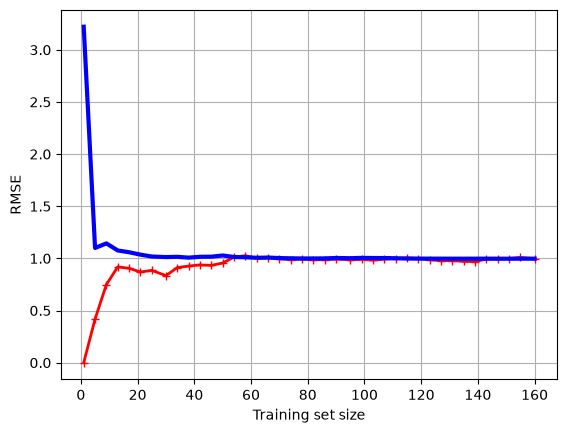

In [13]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve( 
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv = 5, scoring="neg_root_mean_squared_error")

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label ="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()


## Regularized LINEAR models
We can regularize a linear model by constraining it's weights. 3 ways:
1. Ridge Regression aka Tikhonov regularization
2. Lasso Regression (Least Absolute Shrinkage and Selection Regression)
3. Elastic net regression

### Ridge regression
a regularization term $\frac{\alpha}{m}\sum_{i=1}^{n}\theta_i^{2}$ is added to the Mean Square Error  
This forces the learning algorithm to keep the model weights ($\theta_i$) as small as possible, preventing it from stretching itself too much to fit every data point.   
The regularization term is added to the cost function only during training

The Ridge regression cost function:
$J(\theta) = MSE(\theta) + \frac{\alpha}{m}\sum_{i=1}^{n}\theta_i^{2}$

__warning__: Should use StandardScaler before performing ridge regression, as it is sensitive to the scale of the input features

__Closed-form solution__:
$$ \hat{\theta} = (\mathbf{X^T}\mathbf{X} + \alpha\mathbf{A})^{-1}\mathbf{X^T}y $$

In [14]:
#perform ridge regression with sklearn using a closed form solution (with Cholesky factorization)
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X,y)
ridge_reg.predict([[1.5]])

array([8.68256397])

In [19]:
#ridge regression using stochastic gradient descent
sgd_reg = SGDRegressor(
    penalty="l2" , #ridge regression penalty type  - alpha * l2 norm of weight vector
    alpha =0.1/m , #regularization hyperparameter
    tol=None,
    max_iter=1000, eta0 =0.01, random_state=42)

sgd_reg.fit(X,y.ravel())
sgd_reg.predict([[1.5]])

array([8.68217123])

In [22]:
#RidgeCV - performs ridge regression but automatically tunes hyperparemeters using cross-validation
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(alphas = [1e-3, 1e-2, 1e-1, 1], cv=3, fit_intercept=False)
ridgecv.fit(X,y)
ridgecv.predict([[1.5]])


array([9.22060514])

In [23]:
ridgecv.score(X,y)

0.03862480912191302

### Lasso Regression
Just like ridge it adds a regularization term to the cost function but uses the $l_1$ norm of the weight
vector 
$$ J(\theta) = MSE(\theta) + 2\alpha \sum_{i=1}^{n}|\theta_i| $$
Lasso regression tends to set the weights of the least important features to zero i.e it automatically outputs a sparse model with few nonzero feature weights

In [24]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X,y)
lasso_reg.predict([[1.5]])

array([8.52375636])

### Early Stopping
A different way to regularize iterative learning algorithms is to stop training when the validation error reaches a minimum.  
The validation error starting to go back up indicates the model has started to overfit the training data. Sometimes the validation
error does a _double descent_.

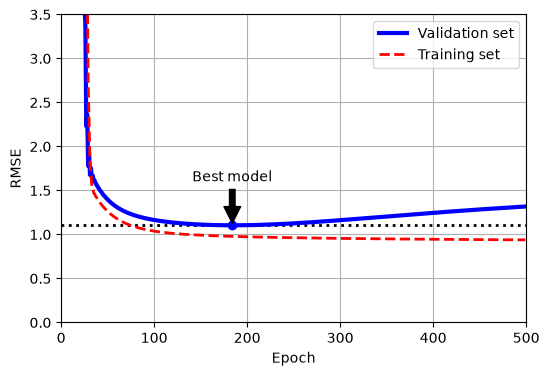

In [12]:
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(seed=42)
m=200
X= 6 * rng.random((m,1)) - 3
y = 0.5 * X**2 + X + 2 + rng.standard_normal((m,1))
X_train, y_train = X[: m //2], y[: m //2, 0 ]
X_valid, y_valid = X[m //2:], y[m //2 : ,0]

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False), StandardScaler())

X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid) #already fitted
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse  = float('inf')
train_errors, val_errors = [], []


for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    #evaluate training error also
    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = root_mean_squared_error(y_train, y_train_predict)
    val_errors.append(val_error)
    train_errors.append(train_error)

best_epoch = np.argmin(val_errors) #return indices of the minimum val_errors
plt.figure(figsize=(6,4))
plt.annotate('Best model', xy=(best_epoch, best_valid_rmse),
             xytext=(best_epoch, best_valid_rmse + 0.5), ha="center", arrowprops = dict(facecolor='black', shrink=0.05))

plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(best_epoch, best_valid_rmse, "bo")
plt.plot(train_errors, "r--", linewidth=2, label="Training set")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis([0, n_epochs, 0, 3.5])
plt.legend(loc="upper right")
plt.grid()

plt.show()



## Logistic (Logit) Regression
Classification , the probability that an instance belongs to a particular class (e.g probability an email is spam)
$$ \hat{p} = h_\theta(\mathbf{x}) = \sigma(\theta^T \mathbf{x}) $$

The logistic function:
$$ \sigma(t) = \frac{1}{1 + exp(-t)} $$

The objective for a logistic training model is to minimize the cost function:
$$ c(\theta) = \left\{
    \begin{array}{ll}
    -log(\hat{p}) & \text{if } y=1 \\
    -log(1-\hat{p}) & \text{if } y=0
    \end{array}
    \right.
    $$
for each instance.  
The log loss function for the entire training set:
$$ J(\theta) = \frac{1}{m}\sum_{i=1}^{m}[y^{(i)}log(\hat{p}^{(i)}) + (1 - y^{(i)}) log(1 - \hat{p}{(i)})] $$

Text(0.5, 0, 't')

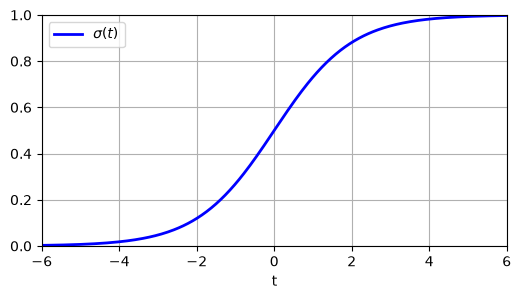

In [46]:
import math
x= np.linspace(-6,6,300)
y=[1/(1 + math.e**(-t)) for t in x]
plt.figure(figsize=(6,3))
plt.plot(x,y, "b-", linewidth=2, label=r"$\sigma(t)$")
plt.grid()
plt.legend(loc="upper left")
plt.axis([-6,6,0.0,1.00])
plt.xlabel("t")

In [4]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)

list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [48]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [50]:
iris.target.head(8)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
Name: target, dtype: int64

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X= iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)
log_reg= LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [58]:
X.shape

(150, 1)

In [54]:
iris.target_names[[0,0,1,0,1,0,2]]

array(['setosa', 'setosa', 'versicolor', 'setosa', 'versicolor', 'setosa',
       'virginica'], dtype='<U10')

Text(0, 0.5, 'Probability')

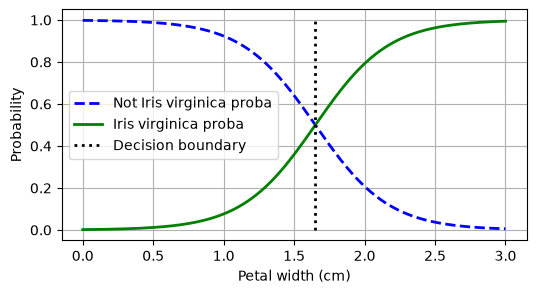

In [6]:
X_new = np.linspace(0,3, 1000).reshape(-1,1) #column vector
y_proba = log_reg.predict_proba(X_new)    #note predict_proba instead of predict()
decision_boundary = X_new[y_proba[:,1] >= 0.5][0,0]

plt.figure(figsize=(6,3))
plt.plot(X_new, y_proba[:,0], "b--", linewidth=2, label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:,1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0,1], "k:", linewidth = 2, label="Decision boundary")
plt.grid()
plt.legend(loc="center left")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")

In [65]:
decision_boundary

np.float64(1.6516516516516517)

In [66]:
log_reg.predict([[1.7],[1.5]])

array([ True, False])

(np.float64(2.9), np.float64(7.0), np.float64(0.8), np.float64(2.7))

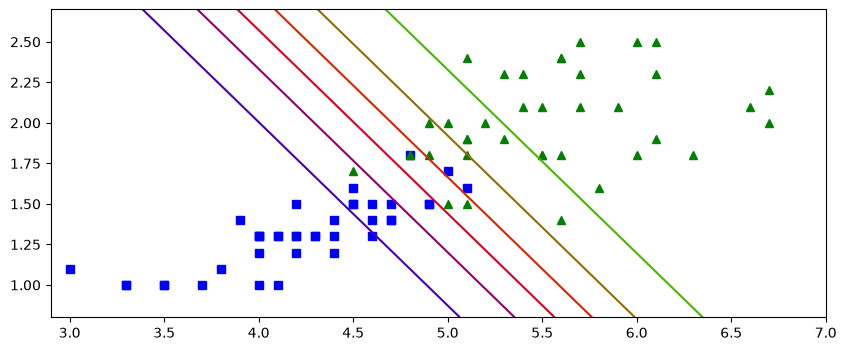

In [33]:
X= iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

x0, x1 = np.meshgrid(np.linspace(2.9,7,500).reshape(-1,1),
                     np.linspace(0.8,2.7,200).reshape(-1,1))

log_reg = LogisticRegression(C=2, random_state=42)
log_reg.fit(X_train, y_train)

X_new = np.c_[x0.ravel(), x1.ravel()]
y_proba = log_reg.predict_proba(X_new)
zz= y_proba[:,1].reshape(x0.shape)

plt.figure(figsize=(10,4))
plt.plot(X_train[y_train==0, 0], X_train[y_train ==0,1],"bs")
plt.plot(X_train[y_train ==1, 0], X_train[y_train ==1], "g^")
contour = plt.contour(x0,x1,zz, cmap=plt.cm.brg)
plt.axis([2.9,7,0.8,2.7])

### Softmax Regression (multinomial logistic regression)

$$ \hat{p_k} = \sigma(s(\mathbf{x}))_k = \frac{exp(s_k(\mathbf{x}))}{\sum_{j=1}^{K} exp(s_j(\mathbf{x}))} $$

where 
$$ s_k(\mathbf{x}) = (\sigma^{(k)})^T \mathbf{x} $$
and $K$ is the number of classes  

Softmax predicts only one class at a time.

In [34]:
x=iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42) #LogisticRegression uses softmax automatically if more than 2 classes
softmax_reg.fit(X_train, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",30
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver

In [35]:
softmax_reg.predict([[5,2]]) #5cm long and 2cm wide petal

array([2])

In [36]:
softmax_reg.predict_proba([[5,2]]).round(2)

array([[0.  , 0.04, 0.96]])

__Batch Gradient Descent with early stopping for Softmax Regression__

In [39]:
y=y.values

In [56]:
#add bias term to X
X_with_bias = np.c_[np.ones(len(X)), X]
test_ratio=0.2
validation_ratio=0.2
total_size = len(X_with_bias)

test_size = int(total_size * test_ratio)
validation_size = int(total_size * validation_ratio)
train_size = total_size - test_size -validation_size

rng = np.random.default_rng(seed=42)
rnd_indices = rng.permutation(total_size)

X_train = X_with_bias[rnd_indices[:train_size]]
y_train = y[rnd_indices[:train_size]]
X_valid = X_with_bias[rnd_indices[train_size:-test_size]]
y_valid = y[rnd_indices[train_size: -test_size]]
X_test = X_with_bias[rnd_indices[-test_size:]]
y_test = y[rnd_indices[-test_size:]]
                           

In [44]:
y_train

array([1, 1, 2, 0, 2, 2, 1, 2, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 2, 1, 0, 2,
       2, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 2, 1, 0, 2, 0, 2, 0, 1, 2, 2, 2,
       0, 1, 1, 1, 2, 0, 1, 2, 2, 0, 1, 1, 0, 0, 1, 2, 1, 1, 0, 0, 2, 1,
       0, 1, 1, 1, 2, 2, 1, 0, 1, 2, 2, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 2,
       1, 1])

In [45]:
def to_one_hot(y):
    return np.diag(np.ones(y.max() + 1))[y]

In [49]:
np.diag(np.ones(y.max() +1))[[1,2,0,1]]

array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [53]:
Y_train_one_hot = to_one_hot(y_train)
Y_valid_one_hot = to_one_hot(y_valid)
Y_test_one_hot = to_one_hot(y_test)



In [57]:
mean = X_train[:,1:].mean(axis=0)
std = X_train[:, 1:].std(axis=0)
X_train[:,1:] = (X_train[:,1:] - mean) / std
X_valid[:,1:] = (X_valid[:,1:] - mean) /std
X_test[:,1:] = (X_test[:,1:] - mean) /std

In [58]:
def softmax(logits):
    exps = np.exp(logits)
    exp_sums = exps.sum(axis=1,  keepdims=True)
    return exps /exp_sums

In [59]:
n_inputs = X_train.shape[1]
n_outputs = len(np.unique(y_train))

In [72]:
eta = 0.5
n_epochs = 5001
m = len(X_train)
epsilon= 1e-5
alpha = 0.01

rng = np.random.default_rng(seed=42)
Theta = rng.standard_normal((n_inputs, n_outputs))

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)
    #if epoch % 1000 == 0:
    #    Y_proba_valid = softmax(X_valid @ Theta)
    #    xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
    #    print(epoch, xentropy_losses.sum(axis=1).mean())
    error = Y_proba - Y_train_one_hot
    gradients = 1 / m * X_train.T @ error
    gradients += np.r_[np.zeros([1,n_outputs]), alpha * Theta[1:]]  #no regularization for the top row thetas, theta_0
    Theta = Theta - eta * gradients

In [61]:
X_train.shape, Theta.shape

((90, 3), (3, 3))

In [64]:
Theta

array([[-1.23843975,  5.9045082 , -4.65088428],
       [-6.53446858, -2.85065468,  7.07247328],
       [-6.919744  , -0.36831947,  7.08286012]])

In [68]:
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

np.float64(0.9333333333333333)

In [71]:
np.r_[np.zeros([1,n_outputs]), Theta[1:]]

array([[ 0.        ,  0.        ,  0.        ],
       [-6.53446858, -2.85065468,  7.07247328],
       [-6.919744  , -0.36831947,  7.08286012]])

In [73]:
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

np.float64(0.9666666666666667)